# Fase 2 — Motor Predictivo Completo · Flota 794AC Quellaveco

## Objetivo

Construir el **motor predictivo completo** del SaaS de mantenimiento predictivo con tres capacidades:

1. **Clasificador de estado futuro** — predecir si la próxima muestra será NORMAL / PRECAUCIÓN / CRÍTICO
2. **Regresor de valores t+1** — predecir los valores numéricos de cada variable analítica
3. **Estimador de horas restantes** — estimar cuántas horas de operación quedan antes de estado CRÍTICO

### Hallazgos de Fase 1 que guían el diseño

| Hallazgo | Implicación para Fase 2 |
|----------|------------------------|
| Umbral de quiebre a ~400-450h de producto | `horas_actuales` es feature crítico |
| Baseline RF logra R² > 0.92 con features de lag | Los lags son altamente predictivos |
| Rolling mean tenía data leakage (incluía t) | **Corregido**: `shift(1)` antes de todo rolling |
| Early warnings: Potasio +301%, Cobre +161% | Incluir estas variables como features |
| Ventana PRECAUCIÓN → CRÍTICO: ~434h (mediana) | Base para el modelo de supervivencia |
| Autocorrelaciones: Hollín 0.81, TBN 0.53 | Variables más predecibles = targets primarios |

### Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Configuración e importaciones |
| 1 | Carga y construcción de features (sin data leakage) |
| 2 | Modelo A: Clasificador de estado futuro |
| 3 | Modelo B: Regresor de variables t+1 |
| 4 | Análisis SHAP (interpretabilidad) |
| 5 | Modelo C: Estimador de horas restantes hasta CRÍTICO |
| 6 | Evaluación por equipo |
| 7 | Función de predicción en producción |
| 8 | Exportación final y resumen ejecutivo |

## SECCIÓN 0 — Configuración

In [11]:
import os, json, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
import optuna
import shap

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette('husl')

os.makedirs('outputs_fase2', exist_ok=True)
os.makedirs('models', exist_ok=True)

FILE_PATH    = r'c:\Users\lbrya\OneDrive\Escritorio\ACEITES_MINERIA\DATA FLOTA 794AC - MOTOR ORIGINAL QUELLAVECO_R4L 2024.xlsx'
SHEET_NAME   = '794AC QUELLA'
N_LAGS       = 5
N_TRIALS     = 50
RANDOM_STATE = 42

VARS_LAG = [
    'TBN (mg KOH/g)',
    'Viscosidad a 100 °C cSt',
    'Hollin ABS/01 mm',
    'Fierro ppm',
    'Oxidación ABS/01 mm',
    'Sulfatación ABS/01 mm',
    'Nitración ABS/01 mm',
    'Cobre ppm',
    'Potasio ppm',
    'Silicio ppm',
    'Aluminio ppm',
    'Cromo ppm',
]

COLORES_ESTADO = {'NORMAL': '#2ecc71', 'PRECAUCION': '#f39c12', 'CRITICO': '#e74c3c'}

print("✓ Configuración cargada")

✓ Configuración cargada


## SECCIÓN 1 — Carga y Construcción de Features (SIN Data Leakage)

### 1.1 — Carga de datos

In [12]:
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Hora_Producto'] = pd.to_numeric(df['Hora_Producto'], errors='coerce')
for col in VARS_LAG:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

estado_map = {'NORMAL': 0, 'PRECAUCION': 1, 'CRITICO': 2}
df['Estado_num'] = df['Estado'].map(estado_map)
df = df.sort_values(['Equipo', 'Hora_Producto']).reset_index(drop=True)

print(f"Dataset cargado: {df.shape}")
print(f"Distribución de estados:\n{df['Estado'].value_counts(normalize=True).mul(100).round(1)}")

Dataset cargado: (3719, 59)
Distribución de estados:
Estado
PRECAUCION    56.4
CRITICO       30.8
NORMAL        12.8
Name: proportion, dtype: float64


### 1.2 — Construcción de features SIN data leakage

**Regla crítica:** todos los features de la muestra *t* se calculan EXCLUSIVAMENTE con datos de *t-1, t-2, …, t-N*. El valor de *t* nunca participa en el cálculo de sus propios features.

Features generados por variable:
- `lag_k`: valor en *t-k* (k = 1…5)
- `delta_k`: diferencia *t-k* menos *t-(k+1)* (tasa de cambio entre lags)
- `rollmean_w` / `rollstd_w`: media y desviación rolling de ventana *w* sobre valores **anteriores a t** (`shift(1)` antes de rolling)
- `trend`: pendiente de regresión lineal sobre las últimas 3 muestras previas

Features de contexto:
- `horas_actuales`, `horas_desde_ultima`, `es_cambio_aceite`, `estado_lag1`, `estado_lag2`

**Cambios de aceite:** cuando `Hora_Producto` decrece, se invalidan todos los lags que crucen ese límite.

In [13]:
def build_features(df, vars_lag, n_lags):
    """
    Construye dataset de features para prediccion t+1.
    Todos los features usan SOLO muestras anteriores a t (shift >= 1).
    Los lags que cruzan un cambio de aceite se invalidan a NaN.
    """
    def lin_slope(x):
        vals = x.dropna()
        if len(vals) < 2:
            return np.nan
        xi = np.arange(len(vals))
        return np.polyfit(xi, vals.values, 1)[0]

    dfs = []
    for equipo, grp in df.groupby('Equipo'):
        grp = grp.sort_values('Hora_Producto').copy().reset_index(drop=True)
        # Copiar columnas meta + valores originales de las variables (son los targets)
        cols_meta = ['Equipo', 'Fecha', 'Hora_Producto', 'Estado', 'Estado_num']
        cols_vars_orig = [v for v in vars_lag if v in grp.columns]
        feat = grp[cols_meta + cols_vars_orig].copy()

        # Detectar cambios de aceite (hora actual < hora anterior)
        delta_hora = grp['Hora_Producto'].diff()
        cambio_aceite = (delta_hora < 0)

        # Construir un "grupo de ciclo de aceite": se incrementa en cada cambio
        ciclo_id = cambio_aceite.cumsum()

        for var in vars_lag:
            if var not in grp.columns:
                continue
            s = grp[var]

            for k in range(1, n_lags + 1):
                col_name = f'lag{k}_{var[:18]}'
                feat[col_name] = s.shift(k)
                # Invalidar si el lag cruza un cambio de aceite
                ciclo_shifted = ciclo_id.shift(k)
                feat.loc[ciclo_id != ciclo_shifted, col_name] = np.nan

            for k in range(1, n_lags):
                col_name = f'delta{k}_{var[:18]}'
                feat[col_name] = s.shift(k) - s.shift(k + 1)
                ciclo_k1 = ciclo_id.shift(k + 1)
                feat.loc[ciclo_id != ciclo_k1, col_name] = np.nan

            # Rolling sobre shift(1) para no incluir t
            s_shifted = s.shift(1)
            for w in [3, 5]:
                feat[f'rollmean{w}_{var[:15]}'] = s_shifted.rolling(w, min_periods=2).mean()
                feat[f'rollstd{w}_{var[:15]}']  = s_shifted.rolling(w, min_periods=2).std()

            feat[f'trend_{var[:18]}'] = (
                s_shifted.rolling(3, min_periods=2).apply(lin_slope, raw=False)
            )

        feat['horas_actuales']      = grp['Hora_Producto']
        feat['horas_desde_ultima']  = delta_hora
        feat['es_cambio_aceite']    = cambio_aceite.astype(int)
        feat['estado_lag1']         = grp['Estado_num'].shift(1)
        feat['estado_lag2']         = grp['Estado_num'].shift(2)

        dfs.append(feat)

    return pd.concat(dfs, ignore_index=True)


df_feat = build_features(df, VARS_LAG, N_LAGS)

# Eliminar filas sin suficientes lags
min_lag_col = f'lag{N_LAGS}_{VARS_LAG[0][:18]}'
df_feat = df_feat.dropna(subset=[min_lag_col]).reset_index(drop=True)

# Columnas que NO son features: metadatos + variables originales (targets)
meta_cols = ['Equipo', 'Fecha', 'Hora_Producto', 'Estado', 'Estado_num'] + \
            [v for v in VARS_LAG if v in df_feat.columns]
feat_cols = [c for c in df_feat.columns if c not in meta_cols]

print(f"Dataset con features: {df_feat.shape}")
print(f"Features construidas: {len(feat_cols)}")
print(f"\nMuestras validas por equipo (top 10):")
print(df_feat.groupby('Equipo').size().sort_values(ascending=False).head(10))

# Guardar lista de features para produccion
with open('models/feat_cols.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)
print(f"\n✓ feat_cols.json guardado ({len(feat_cols)} features)")

Dataset con features: (3560, 190)
Features construidas: 173

Muestras validas por equipo (top 10):
Equipo
HT012    173
HT005    169
HT011    163
HT001    163
HT006    155
HT002    154
HT007    150
HT016    149
HT003    147
HT015    135
dtype: int64

✓ feat_cols.json guardado (173 features)


## SECCIÓN 2 — Modelo A: Clasificador de Estado Futuro

Predice si el estado de la próxima muestra (*t+1*) será **NORMAL / PRECAUCIÓN / CRÍTICO**.

- Split **temporal** 80/20 (sin shuffle) para respetar la secuencia cronológica.
- Optimización de hiperparámetros con **Optuna** (50 trials).
- Comparación LightGBM vs XGBoost.
- `class_weight='balanced'` para compensar el desbalance (NORMAL = 12.8%).

### 2.1 — Preparar datos de clasificación

In [14]:
X_clf = df_feat[feat_cols].copy()
y_clf = df_feat['Estado_num'].values

# Mapeo inverso para reportes
estado_map_inv = {0: 'NORMAL', 1: 'PRECAUCION', 2: 'CRITICO'}
label_names = [estado_map_inv[i] for i in sorted(estado_map_inv.keys())]

X_clf = X_clf.fillna(X_clf.median())

split_idx = int(len(X_clf) * 0.80)
X_train_c, X_test_c = X_clf.iloc[:split_idx], X_clf.iloc[split_idx:]
y_train_c, y_test_c = y_clf[:split_idx], y_clf[split_idx:]

print(f"Train: {len(X_train_c)} | Test: {len(X_test_c)}")
for split_name, y_split in [('TRAIN', y_train_c), ('TEST', y_test_c)]:
    print(f"\nDistribucion en {split_name}:")
    for v, n in zip(*np.unique(y_split, return_counts=True)):
        print(f"  {estado_map_inv[v]}: {n} ({n/len(y_split)*100:.1f}%)")

Train: 2848 | Test: 712

Distribucion en TRAIN:
  NORMAL: 338 (11.9%)
  PRECAUCION: 1628 (57.2%)
  CRITICO: 882 (31.0%)

Distribucion en TEST:
  NORMAL: 36 (5.1%)
  PRECAUCION: 422 (59.3%)
  CRITICO: 254 (35.7%)


### 2.2 — LightGBM con optimización Optuna

In [15]:
def objective_lgb_clf(trial):
    params = {
        'objective':         'multiclass',
        'num_class':         3,
        'metric':            'multi_logloss',
        'verbosity':         -1,
        'boosting_type':     'gbdt',
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=False)
    scores = []
    for tr_idx, val_idx in cv.split(X_train_c, y_train_c):
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_c.iloc[tr_idx], y_train_c[tr_idx],
                  eval_set=[(X_train_c.iloc[val_idx], y_train_c[val_idx])],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
        preds = model.predict(X_train_c.iloc[val_idx])
        scores.append(accuracy_score(y_train_c[val_idx], preds))
    return np.mean(scores)

print("Optimizando LightGBM (clasificador de estado)...")
study_lgb_clf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_lgb_clf.optimize(objective_lgb_clf, n_trials=N_TRIALS, show_progress_bar=True)

best_params_lgb_clf = study_lgb_clf.best_params.copy()
best_params_lgb_clf.update({
    'objective': 'multiclass', 'num_class': 3,
    'class_weight': 'balanced', 'random_state': RANDOM_STATE,
    'verbosity': -1, 'n_jobs': -1
})

lgb_clf = lgb.LGBMClassifier(**best_params_lgb_clf)
lgb_clf.fit(X_train_c, y_train_c)
y_pred_lgb = lgb_clf.predict(X_test_c)
acc_lgb = accuracy_score(y_test_c, y_pred_lgb)

print(f"\n✓ LightGBM Accuracy: {acc_lgb:.4f}")
print(f"  Mejor CV score: {study_lgb_clf.best_value:.4f}")
print(f"\nReporte de Clasificacion (LightGBM):")
print(classification_report(y_test_c, y_pred_lgb, target_names=label_names))

Optimizando LightGBM (clasificador de estado)...


Best trial: 22. Best value: 0.657343: 100%|██████████| 50/50 [05:45<00:00,  6.91s/it]



✓ LightGBM Accuracy: 0.7725
  Mejor CV score: 0.6573

Reporte de Clasificacion (LightGBM):
              precision    recall  f1-score   support

      NORMAL       0.53      0.50      0.51        36
  PRECAUCION       0.79      0.85      0.82       422
     CRITICO       0.77      0.68      0.72       254

    accuracy                           0.77       712
   macro avg       0.70      0.68      0.69       712
weighted avg       0.77      0.77      0.77       712



### 2.3 — XGBoost como comparación

In [16]:
def objective_xgb_clf(trial):
    params = {
        'objective':        'multi:softmax',
        'num_class':        3,
        'eval_metric':      'mlogloss',
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':     RANDOM_STATE,
        'verbosity':        0,
        'n_jobs':           -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=False)
    scores = []
    for tr_idx, val_idx in cv.split(X_train_c, y_train_c):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train_c.iloc[tr_idx], y_train_c[tr_idx], verbose=False)
        preds = model.predict(X_train_c.iloc[val_idx])
        scores.append(accuracy_score(y_train_c[val_idx], preds))
    return np.mean(scores)

print("Optimizando XGBoost (clasificador de estado)...")
study_xgb_clf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb_clf.optimize(objective_xgb_clf, n_trials=N_TRIALS, show_progress_bar=True)

best_params_xgb_clf = study_xgb_clf.best_params.copy()
best_params_xgb_clf.update({
    'objective': 'multi:softmax', 'num_class': 3,
    'verbosity': 0, 'random_state': RANDOM_STATE, 'n_jobs': -1
})

xgb_clf = xgb.XGBClassifier(**best_params_xgb_clf)
xgb_clf.fit(X_train_c, y_train_c)
y_pred_xgb = xgb_clf.predict(X_test_c)
acc_xgb = accuracy_score(y_test_c, y_pred_xgb)

print(f"\n✓ XGBoost Accuracy: {acc_xgb:.4f}")
print(f"  Mejor CV score: {study_xgb_clf.best_value:.4f}")
print(f"\nReporte de Clasificacion (XGBoost):")
print(classification_report(y_test_c, y_pred_xgb, target_names=label_names))

Optimizando XGBoost (clasificador de estado)...


Best trial: 47. Best value: 0.683315: 100%|██████████| 50/50 [05:34<00:00,  6.68s/it]



✓ XGBoost Accuracy: 0.7865
  Mejor CV score: 0.6833

Reporte de Clasificacion (XGBoost):
              precision    recall  f1-score   support

      NORMAL       0.58      0.39      0.47        36
  PRECAUCION       0.79      0.88      0.84       422
     CRITICO       0.79      0.69      0.74       254

    accuracy                           0.79       712
   macro avg       0.72      0.65      0.68       712
weighted avg       0.78      0.79      0.78       712



### 2.4 — Comparación y matrices de confusión


 COMPARACION DE MODELOS (Clasificacion de Estado)
  LightGBM: 0.7725
  XGBoost:  0.7865
  -> Mejor modelo: XGBoost


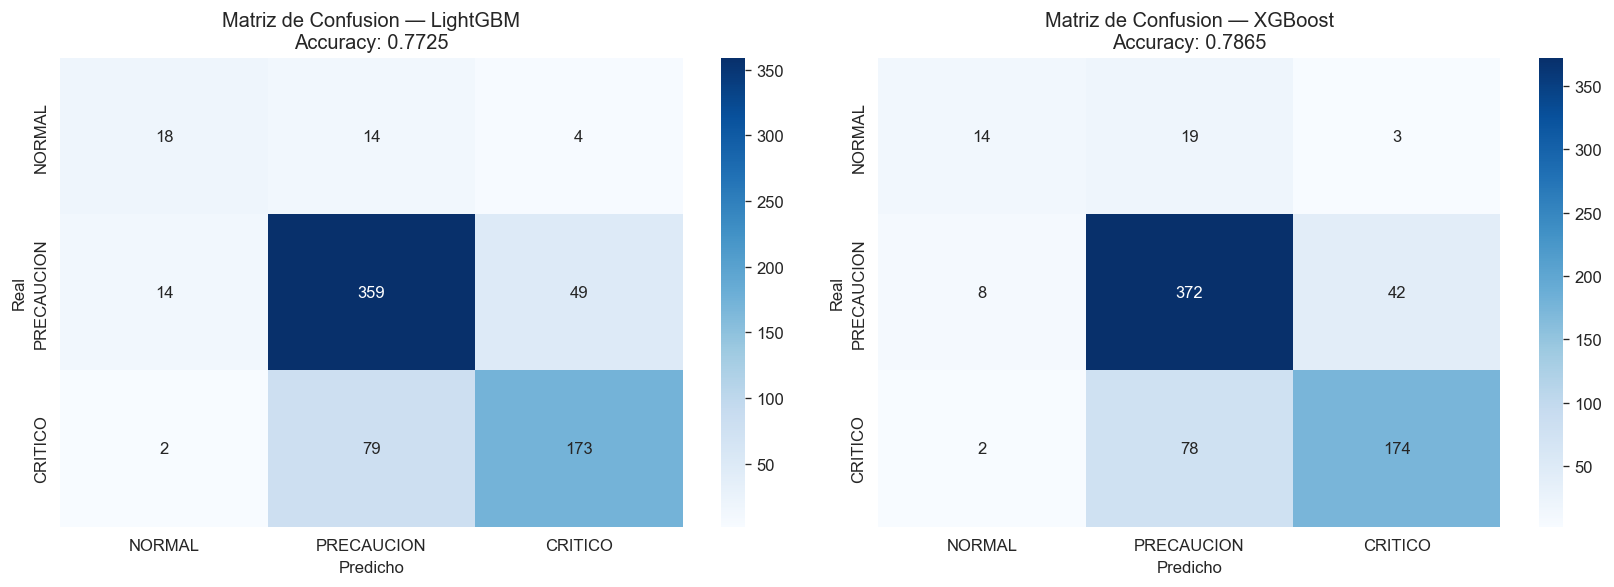

✓ Modelo guardado: models/clasificador_estado_xgboost.pkl


In [17]:
print(f"\n{'='*50}")
print(f" COMPARACION DE MODELOS (Clasificacion de Estado)")
print(f"{'='*50}")
print(f"  LightGBM: {acc_lgb:.4f}")
print(f"  XGBoost:  {acc_xgb:.4f}")

best_clf = lgb_clf if acc_lgb >= acc_xgb else xgb_clf
best_clf_name = 'LightGBM' if acc_lgb >= acc_xgb else 'XGBoost'
y_pred_best_clf = y_pred_lgb if acc_lgb >= acc_xgb else y_pred_xgb
print(f"  -> Mejor modelo: {best_clf_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_lgb, y_pred_xgb], ['LightGBM', 'XGBoost']):
    cm = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'Matriz de Confusion — {title}\n'
                 f'Accuracy: {accuracy_score(y_test_c, y_pred):.4f}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('outputs_fase2/01_confusion_matrix_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(best_clf, f'models/clasificador_estado_{best_clf_name.lower()}.pkl')
print(f"✓ Modelo guardado: models/clasificador_estado_{best_clf_name.lower()}.pkl")

## SECCIÓN 3 — Modelo B: Regresor de Variables t+1

Predice los **valores numéricos** de cada variable analítica en la próxima muestra. Se entrena un modelo LightGBM Regressor **independiente por variable**, cada uno optimizado con Optuna.

### 3.1 — Optimización y entrenamiento

In [18]:
def optimize_lgb_regressor(X_tr, y_tr, n_trials):
    """Optuna optimization para LightGBM regresor."""
    def objective(trial):
        params = {
            'objective':         'regression',
            'metric':            'mae',
            'verbosity':         -1,
            'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state':      RANDOM_STATE,
            'n_jobs':            -1,
        }
        kf = KFold(n_splits=5, shuffle=False)
        maes = []
        for tr_idx, val_idx in kf.split(X_tr):
            model = lgb.LGBMRegressor(**params)
            model.fit(X_tr.iloc[tr_idx], y_tr[tr_idx],
                      eval_set=[(X_tr.iloc[val_idx], y_tr[val_idx])],
                      callbacks=[lgb.early_stopping(30, verbose=False)])
            preds = model.predict(X_tr.iloc[val_idx])
            maes.append(mean_absolute_error(y_tr[val_idx], preds))
        return np.mean(maes)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


print("=" * 65)
print(" REGRESION t+1 — LightGBM optimizado por variable")
print("=" * 65)

regression_results = []
regression_models  = {}

for var in VARS_LAG:
    if var not in df_feat.columns:
        continue

    y_reg = df_feat[var].values
    valid_mask = ~np.isnan(y_reg)
    X_reg = X_clf[valid_mask].copy()
    y_reg = y_reg[valid_mask]

    if len(y_reg) < 200:
        print(f"  ! {var[:30]}: insuficientes muestras ({len(y_reg)}), saltando.")
        continue

    split = int(len(X_reg) * 0.80)
    X_tr, X_te = X_reg.iloc[:split], X_reg.iloc[split:]
    y_tr, y_te = y_reg[:split], y_reg[split:]

    print(f"  Optimizando {var[:30]}...", end=' ', flush=True)
    best_hp = optimize_lgb_regressor(X_tr, y_tr, N_TRIALS)
    best_hp.update({'objective': 'regression', 'verbosity': -1,
                    'random_state': RANDOM_STATE, 'n_jobs': -1})

    model = lgb.LGBMRegressor(**best_hp)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    mape = np.mean(np.abs((y_te - y_pred) / (np.abs(y_te) + 1e-8))) * 100

    regression_results.append({
        'Variable': var, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
        'R2': round(r2, 4), 'MAPE_%': round(mape, 2), 'N_test': len(y_te)
    })
    regression_models[var] = model

    print(f"MAE={mae:.4f} | R2={r2:.4f} | MAPE={mape:.1f}%")

    safe_name = var.replace(' ', '_').replace('/', '_').replace('°', 'deg')[:30]
    joblib.dump(model, f'models/regresor_{safe_name}.pkl')

reg_df = pd.DataFrame(regression_results)
print(f"\n{'='*65}")
print("Resumen de regresores:")
print(reg_df.to_string(index=False))
reg_df.to_excel('outputs_fase2/02_resultados_regresion_t1.xlsx', index=False)
print("✓ Resultados guardados en outputs_fase2/02_resultados_regresion_t1.xlsx")

 REGRESION t+1 — LightGBM optimizado por variable
  Optimizando TBN (mg KOH/g)... MAE=0.3414 | R2=0.4910 | MAPE=109351160.0%
  Optimizando Viscosidad a 100 °C cSt... MAE=0.2263 | R2=0.1063 | MAPE=1.7%
  Optimizando Hollin ABS/01 mm... MAE=0.1227 | R2=0.6717 | MAPE=23.1%
  Optimizando Fierro ppm... MAE=6.7800 | R2=0.4172 | MAPE=43.1%
  Optimizando Oxidación ABS/01 mm... MAE=0.0108 | R2=0.2663 | MAPE=6899031.7%
  Optimizando Sulfatación ABS/01 mm... MAE=0.0107 | R2=0.5154 | MAPE=10407016.3%
  Optimizando Nitración ABS/01 mm... MAE=0.0116 | R2=0.4327 | MAPE=9527062.0%
  Optimizando Cobre ppm... MAE=0.5209 | R2=0.1127 | MAPE=2475005305.8%
  Optimizando Potasio ppm... MAE=1.7309 | R2=-1.5918 | MAPE=13043361828.6%
  Optimizando Silicio ppm... MAE=3.7027 | R2=0.0666 | MAPE=9566790323.7%
  Optimizando Aluminio ppm... MAE=0.3884 | R2=0.0727 | MAPE=1136004509.1%
  Optimizando Cromo ppm... MAE=0.1259 | R2=-0.1132 | MAPE=830846162.8%

Resumen de regresores:
               Variable    MAE    RMSE  

### 3.2 — Visualización predicción vs real (top 4 variables)

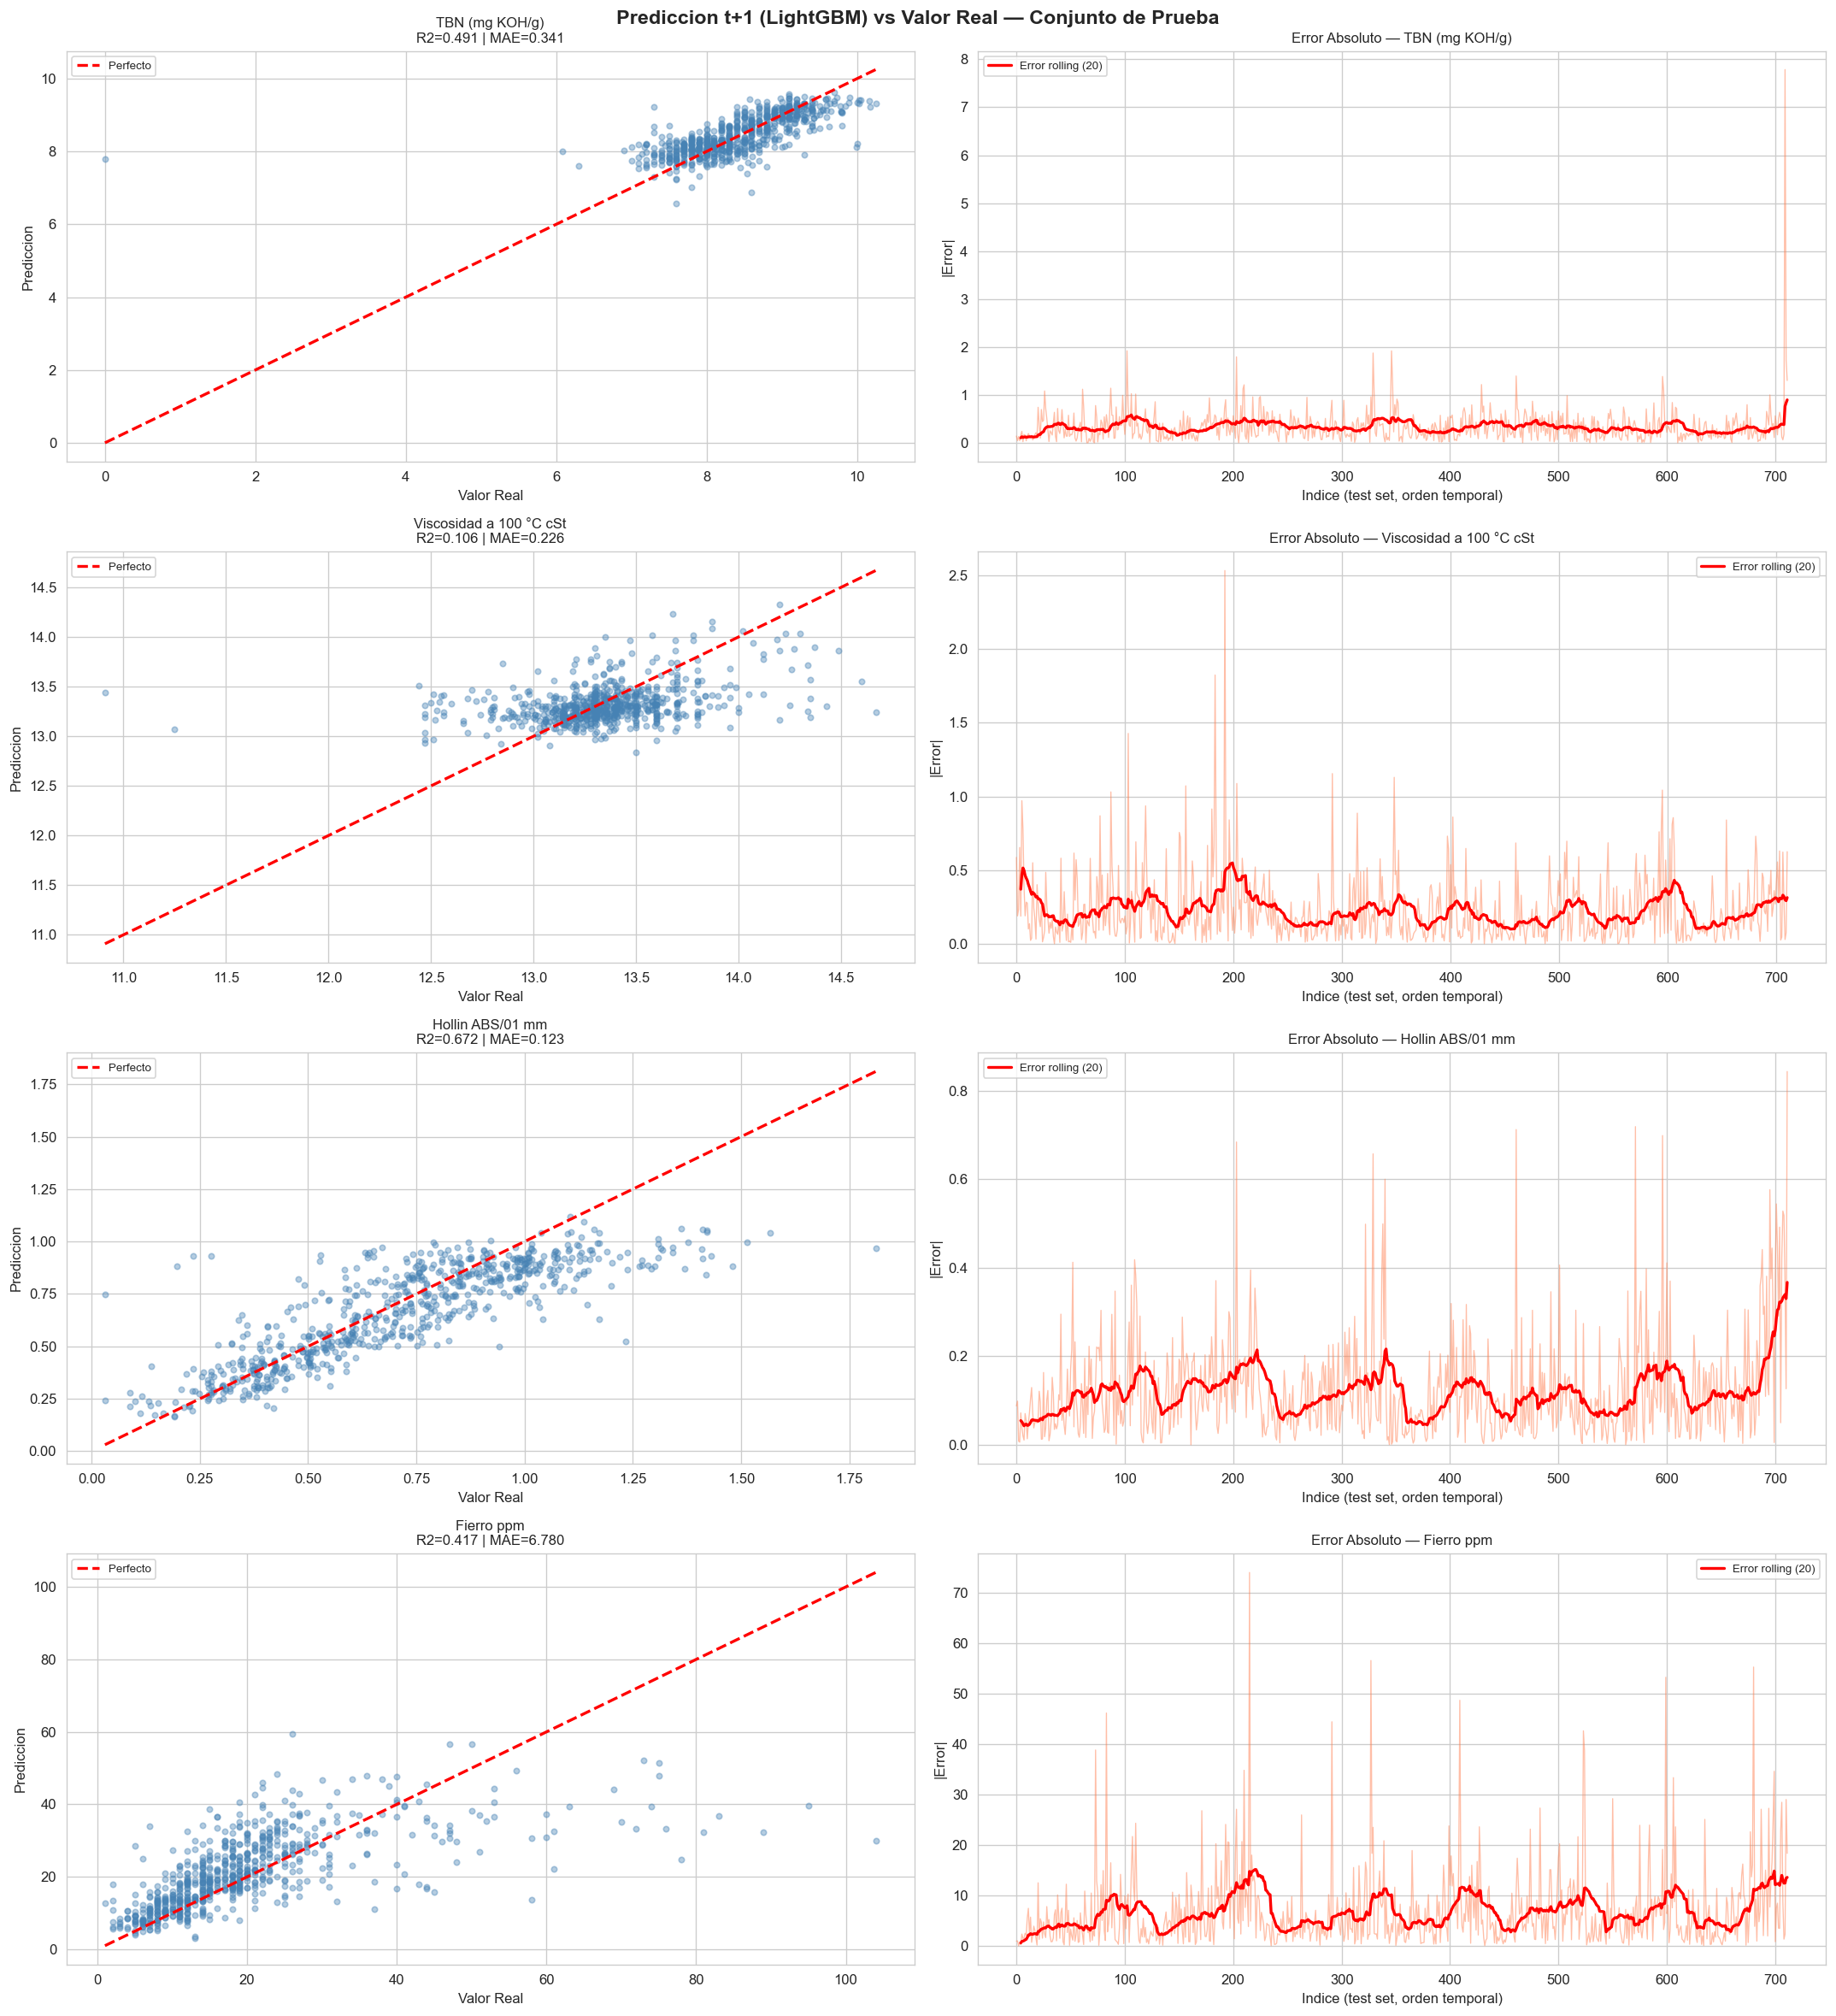

In [19]:
vars_to_plot = [v for v in ['TBN (mg KOH/g)', 'Viscosidad a 100 °C cSt',
                            'Hollin ABS/01 mm', 'Fierro ppm']
                if v in regression_models]

if len(vars_to_plot) == 0:
    vars_to_plot = list(regression_models.keys())[:4]

n_plots = max(1, len(vars_to_plot))
fig, axes = plt.subplots(n_plots, 2, figsize=(18, 5 * n_plots))
if n_plots == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Prediccion t+1 (LightGBM) vs Valor Real — Conjunto de Prueba',
             fontsize=14, fontweight='bold')

for i, var in enumerate(vars_to_plot):
    y_reg = df_feat[var].values
    valid_mask = ~np.isnan(y_reg)
    X_reg = X_clf[valid_mask]
    y_reg = y_reg[valid_mask]
    split = int(len(X_reg) * 0.80)
    y_te = y_reg[split:]
    y_pred = regression_models[var].predict(X_reg.iloc[split:])
    error = np.abs(y_te - y_pred)

    ax_pred = axes[i, 0]
    ax_pred.scatter(y_te, y_pred, alpha=0.4, s=15, c='steelblue')
    lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
    ax_pred.plot(lims, lims, 'r--', linewidth=2, label='Perfecto')
    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    ax_pred.set_title(f'{var}\nR2={r2:.3f} | MAE={mae:.3f}', fontsize=10)
    ax_pred.set_xlabel('Valor Real')
    ax_pred.set_ylabel('Prediccion')
    ax_pred.legend(fontsize=8)

    ax_err = axes[i, 1]
    ax_err.plot(range(len(error)), error, alpha=0.5, linewidth=0.8, color='coral')
    rolling_err = pd.Series(error).rolling(20, min_periods=5).mean()
    ax_err.plot(range(len(rolling_err)), rolling_err, linewidth=2, color='red',
                label='Error rolling (20)')
    ax_err.set_title(f'Error Absoluto — {var[:30]}', fontsize=10)
    ax_err.set_xlabel('Indice (test set, orden temporal)')
    ax_err.set_ylabel('|Error|')
    ax_err.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs_fase2/02b_prediccion_vs_real_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

## SECCIÓN 4 — Análisis SHAP (Interpretabilidad)

### 4.1 — SHAP para el clasificador de estado

Importancia global de features y descomposición por clase (NORMAL / PRECAUCIÓN / CRÍTICO).

Calculando SHAP values para el clasificador de estado...
  SHAP format: 3 clases, shape por clase: (500, 173)


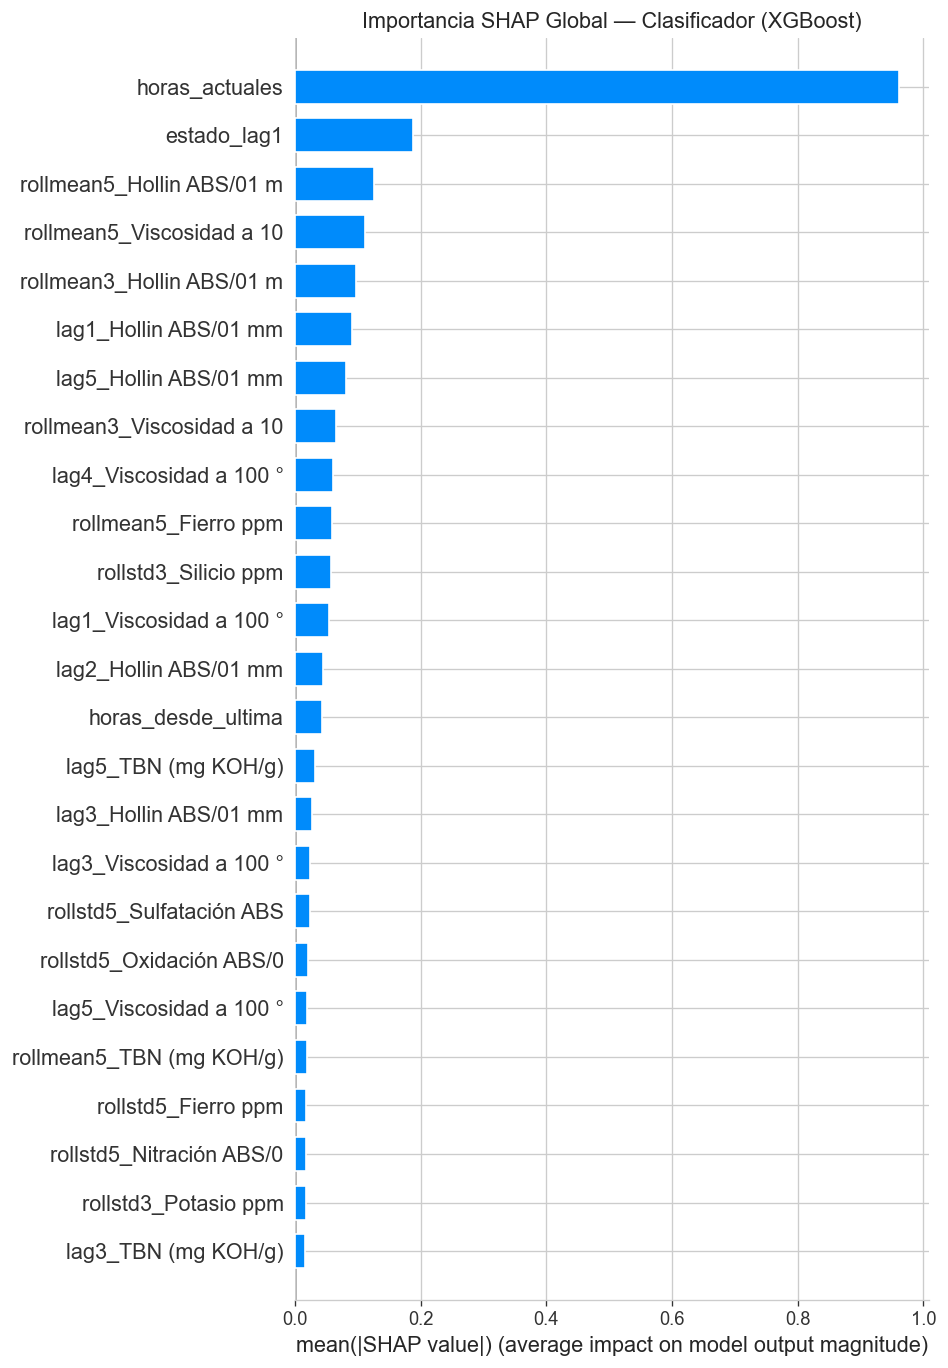

In [22]:
print("Calculando SHAP values para el clasificador de estado...")

X_shap = X_test_c.sample(min(500, len(X_test_c)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_clf)
shap_values_raw = explainer.shap_values(X_shap)

# Normalizar formato: siempre lista de arrays 2D [clase0, clase1, clase2]
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # Formato (n_samples, n_features, n_classes) o (n_classes, n_samples, n_features)
    if shap_values_raw.shape[0] == len(X_shap):
        shap_values = [shap_values_raw[:, :, c] for c in range(shap_values_raw.shape[2])]
    else:
        shap_values = [shap_values_raw[c] for c in range(shap_values_raw.shape[0])]
else:
    shap_values = [shap_values_raw]

print(f"  SHAP format: {len(shap_values)} clases, shape por clase: {shap_values[0].shape}")

# SHAP summary global
fig, ax = plt.subplots(figsize=(12, 10))
shap_abs = np.sum([np.abs(sv) for sv in shap_values], axis=0)
shap.summary_plot(shap_abs, X_shap, plot_type='bar',
                  feature_names=feat_cols, show=False, max_display=25)
plt.title(f'Importancia SHAP Global — Clasificador ({best_clf_name})', fontsize=13)
plt.tight_layout()
plt.savefig('outputs_fase2/03_shap_clasificador.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 — SHAP por clase y ranking global

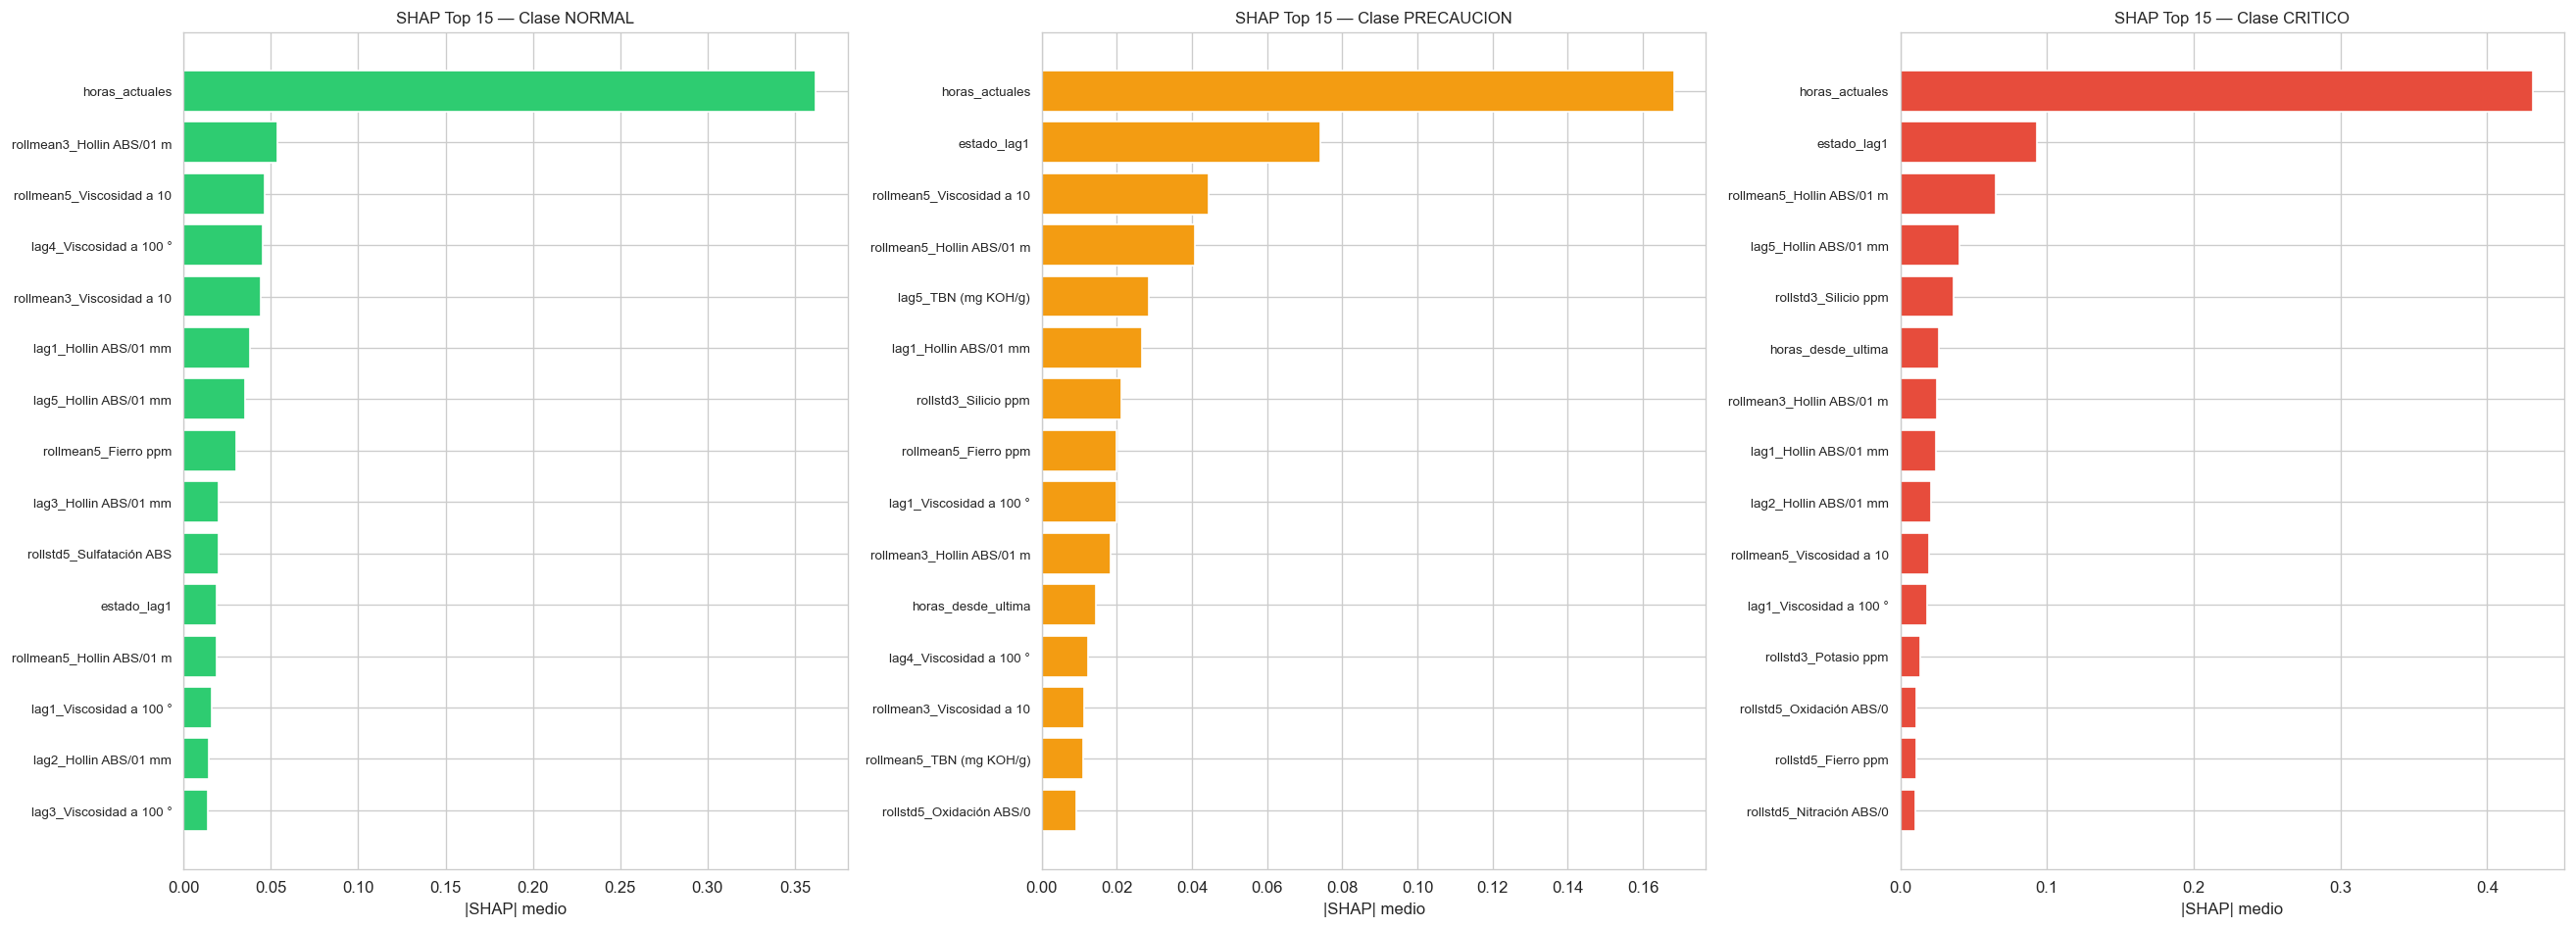


Top 30 features mas importantes (SHAP global):
                  Feature  SHAP_importancia
           horas_actuales          0.961347
              estado_lag1          0.186664
rollmean5_Hollin ABS/01 m          0.124931
rollmean5_Viscosidad a 10          0.110943
rollmean3_Hollin ABS/01 m          0.097007
    lag1_Hollin ABS/01 mm          0.089551
    lag5_Hollin ABS/01 mm          0.080074
rollmean3_Viscosidad a 10          0.065322
  lag4_Viscosidad a 100 °          0.059553
     rollmean5_Fierro ppm          0.059230
     rollstd3_Silicio ppm          0.057269
  lag1_Viscosidad a 100 °          0.054175
    lag2_Hollin ABS/01 mm          0.043851
       horas_desde_ultima          0.042184
      lag5_TBN (mg KOH/g)          0.031155
    lag3_Hollin ABS/01 mm          0.026707
  lag3_Viscosidad a 100 °          0.023204
 rollstd5_Sulfatación ABS          0.022769
 rollstd5_Oxidación ABS/0          0.020866
  lag5_Viscosidad a 100 °          0.019207
 rollmean5_TBN (mg KOH/g)   

In [23]:
# SHAP por clase (shap_values ya normalizado como lista en la celda anterior)
if len(shap_values) == 3:
    class_names_shap = label_names
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    for i, (sv, cname) in enumerate(zip(shap_values, class_names_shap)):
        shap_imp = pd.DataFrame({
            'Feature': feat_cols,
            'SHAP_mean_abs': np.abs(sv).mean(axis=0)
        }).sort_values('SHAP_mean_abs', ascending=False).head(15)

        axes[i].barh(range(15), shap_imp['SHAP_mean_abs'].values[::-1],
                     color=list(COLORES_ESTADO.values())[i])
        axes[i].set_yticks(range(15))
        axes[i].set_yticklabels(shap_imp['Feature'].values[::-1], fontsize=8)
        axes[i].set_title(f'SHAP Top 15 — Clase {cname}', fontsize=10)
        axes[i].set_xlabel('|SHAP| medio')
    plt.tight_layout()
    plt.savefig('outputs_fase2/04_shap_por_clase.png', dpi=150, bbox_inches='tight')
    plt.show()

# Ranking global: sumar |SHAP| de todas las clases y promediar sobre muestras
global_shap = np.sum([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)

shap_ranking = pd.DataFrame({
    'Feature': feat_cols,
    'SHAP_importancia': global_shap
}).sort_values('SHAP_importancia', ascending=False).head(30)

print("\nTop 30 features mas importantes (SHAP global):")
print(shap_ranking.to_string(index=False))
shap_ranking.to_excel('outputs_fase2/05_shap_ranking.xlsx', index=False)
print("✓ Ranking SHAP guardado")

## SECCIÓN 5 — Modelo C: Estimador de Horas Restantes hasta CRÍTICO

Responde la pregunta: **"¿Cuántas horas de operación le quedan a este camión antes de entrar en CRÍTICO?"**

Para cada muestra que NO es CRÍTICA, se calcula cuántas horas de `Hora_Producto` faltan hasta la primera transición a CRÍTICO posterior. Las muestras sin transición futura se excluyen (censuradas).

### 5.1 — Construir target: horas restantes hasta CRÍTICO

Calculando horas hasta proximo estado CRITICO...
Muestras validas para survival: 2493

Estadisticas de horas restantes:
count    2493.0
mean       59.8
std        78.8
min         1.0
25%         9.0
50%        28.0
75%        76.0
max       439.0
Name: Horas_hasta_critico, dtype: float64


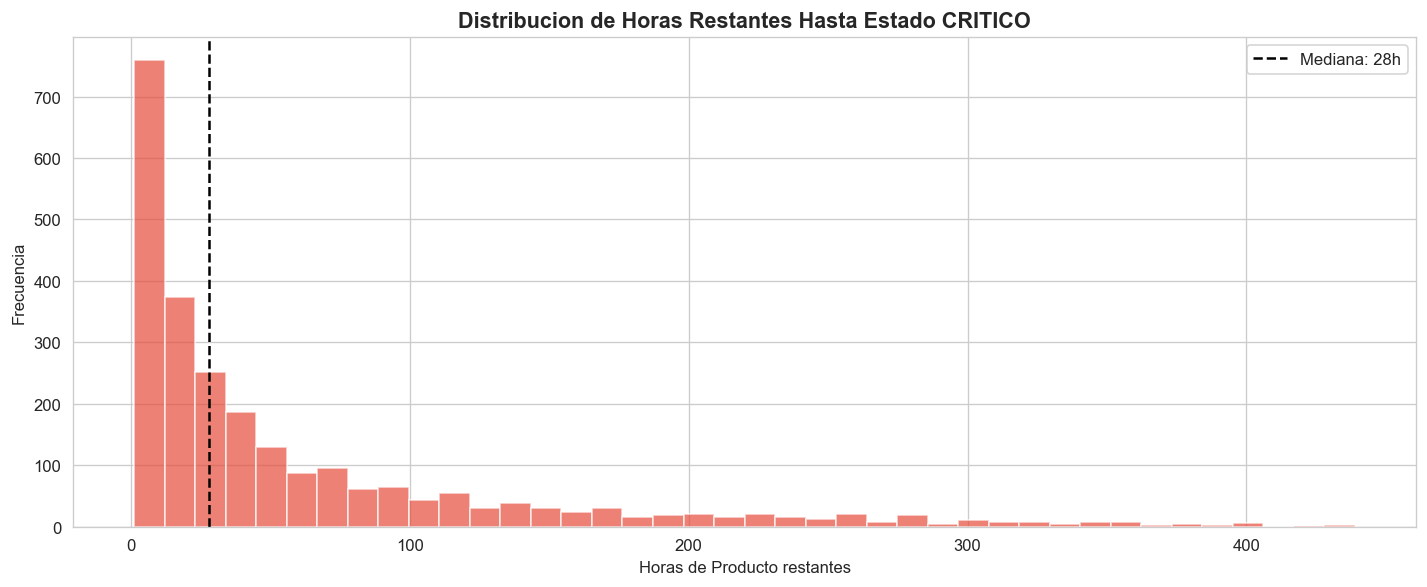

In [24]:
def compute_horas_hasta_critico(df):
    """Para cada muestra no-CRITICA, calcula horas hasta la proxima muestra CRITICA."""
    rows = []
    for equipo, grp in df.groupby('Equipo'):
        grp = grp.sort_values('Hora_Producto').reset_index(drop=True)
        estados = grp['Estado'].values
        horas = grp['Hora_Producto'].values
        fechas = grp['Fecha'].values

        for i in range(len(grp)):
            if estados[i] == 'CRITICO':
                continue
            # Buscar la proxima muestra CRITICA
            futuras = np.where((np.arange(len(grp)) > i) & (estados == 'CRITICO'))[0]
            if len(futuras) == 0:
                continue
            primera = futuras[0]
            horas_restantes = horas[primera] - horas[i]
            if horas_restantes <= 0:
                continue
            rows.append({
                'Equipo': equipo,
                'Fecha': fechas[i],
                'Hora_Producto': horas[i],
                'Estado': estados[i],
                'Horas_hasta_critico': horas_restantes
            })
    return pd.DataFrame(rows)

print("Calculando horas hasta proximo estado CRITICO...")
df_survival = compute_horas_hasta_critico(df)
print(f"Muestras validas para survival: {len(df_survival)}")
print(f"\nEstadisticas de horas restantes:")
print(df_survival['Horas_hasta_critico'].describe().round(1))

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_survival['Horas_hasta_critico'], bins=40,
        color='#e74c3c', alpha=0.7, edgecolor='white')
med = df_survival['Horas_hasta_critico'].median()
ax.axvline(med, color='black', linestyle='--',
           label=f'Mediana: {med:.0f}h')
ax.set_title('Distribucion de Horas Restantes Hasta Estado CRITICO',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Horas de Producto restantes')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('outputs_fase2/06_horas_restantes_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 — Entrenar regresor de supervivencia

Dataset de supervivencia: 3164 muestras
Optimizando modelo de supervivencia...

✓ Modelo de Supervivencia (Horas hasta CRITICO):
  MAE:  46.9 horas
  RMSE: 66.6 horas
  R2:   0.2045
✓ Modelo guardado: models/estimador_horas_hasta_critico.pkl


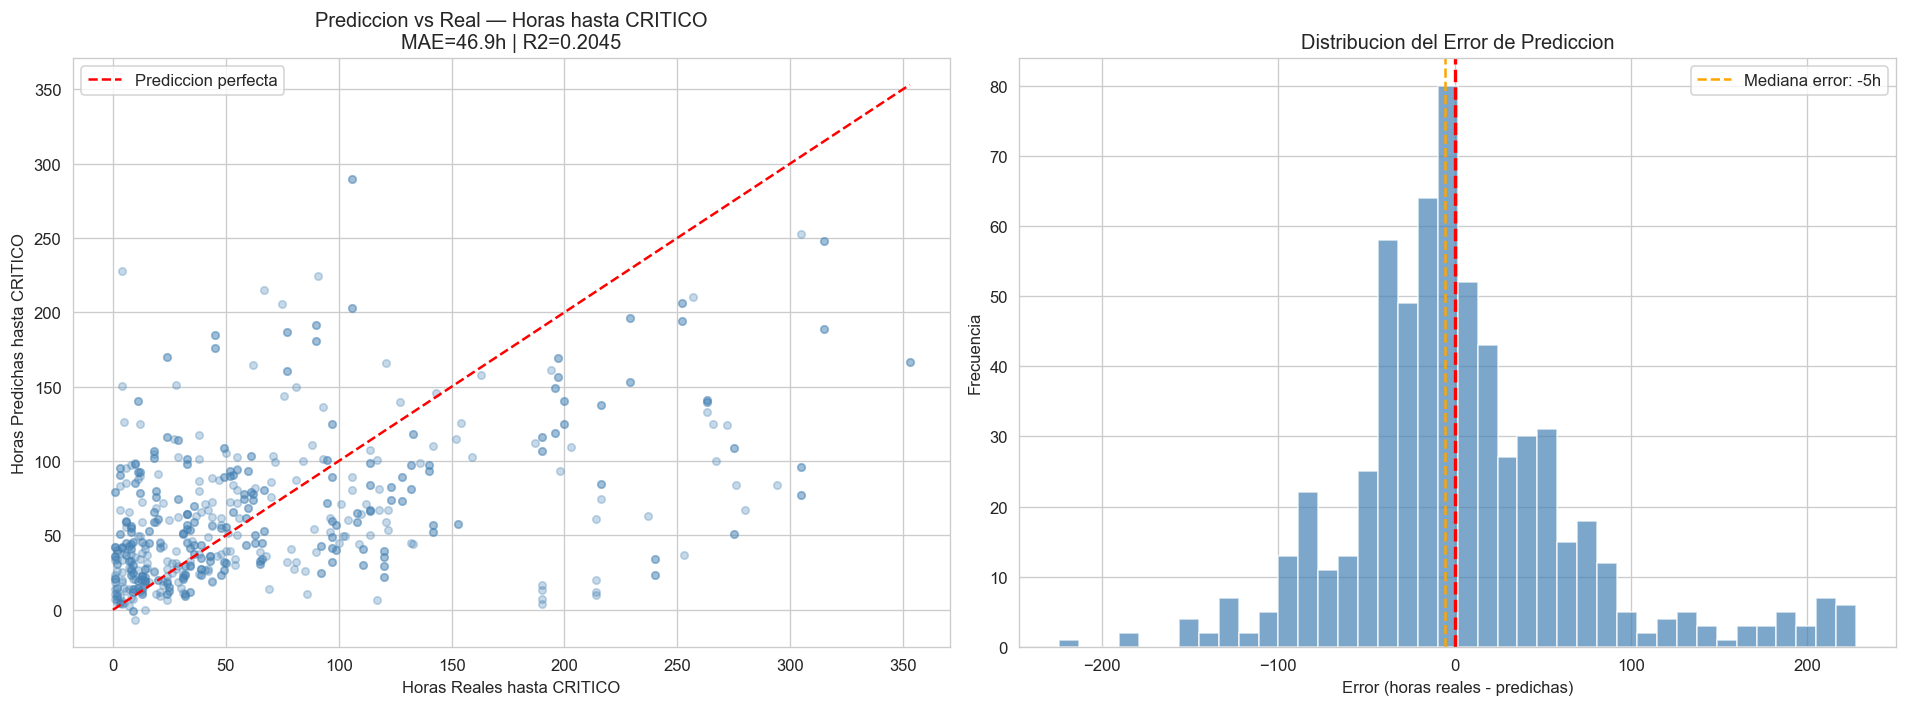

In [25]:
# Merge con features: unir df_survival con df_feat por Equipo + Fecha
df_survival['Fecha'] = pd.to_datetime(df_survival['Fecha'])
df_feat['Fecha'] = pd.to_datetime(df_feat['Fecha'])

df_surv_feat = df_survival.merge(
    df_feat[['Equipo', 'Fecha'] + feat_cols],
    on=['Equipo', 'Fecha'], how='inner'
)

# Eliminar filas con demasiados nulos en features principales
min_feat_valid = 10
valid_count = df_surv_feat[feat_cols].notna().sum(axis=1)
df_surv_feat = df_surv_feat[valid_count >= min_feat_valid].reset_index(drop=True)

X_surv = df_surv_feat[feat_cols].fillna(df_surv_feat[feat_cols].median())
y_surv = df_surv_feat['Horas_hasta_critico'].values

print(f"Dataset de supervivencia: {len(X_surv)} muestras")

split = int(len(X_surv) * 0.80)
X_tr_s, X_te_s = X_surv.iloc[:split], X_surv.iloc[split:]
y_tr_s, y_te_s = y_surv[:split], y_surv[split:]

# Optimizar con Optuna
print("Optimizando modelo de supervivencia...")
best_hp_surv = optimize_lgb_regressor(X_tr_s, y_tr_s, N_TRIALS)
best_hp_surv.update({'objective': 'regression', 'verbosity': -1,
                     'random_state': RANDOM_STATE, 'n_jobs': -1})

surv_model = lgb.LGBMRegressor(**best_hp_surv)
surv_model.fit(X_tr_s, y_tr_s)
y_pred_surv = surv_model.predict(X_te_s)

mae_surv  = mean_absolute_error(y_te_s, y_pred_surv)
rmse_surv = np.sqrt(mean_squared_error(y_te_s, y_pred_surv))
r2_surv   = r2_score(y_te_s, y_pred_surv)

print(f"\n✓ Modelo de Supervivencia (Horas hasta CRITICO):")
print(f"  MAE:  {mae_surv:.1f} horas")
print(f"  RMSE: {rmse_surv:.1f} horas")
print(f"  R2:   {r2_surv:.4f}")

joblib.dump(surv_model, 'models/estimador_horas_hasta_critico.pkl')
print("✓ Modelo guardado: models/estimador_horas_hasta_critico.pkl")

# Scatter prediccion vs real
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(y_te_s, y_pred_surv, alpha=0.3, c='steelblue', s=20)
lim = [0, max(y_te_s.max(), y_pred_surv.max())]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
ax.set_xlabel('Horas Reales hasta CRITICO')
ax.set_ylabel('Horas Predichas hasta CRITICO')
ax.set_title(f'Prediccion vs Real — Horas hasta CRITICO\nMAE={mae_surv:.1f}h | R2={r2_surv:.4f}')
ax.legend()

ax2 = axes[1]
error_surv = y_te_s - y_pred_surv
ax2.hist(error_surv, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.axvline(np.median(error_surv), color='orange', linestyle='--',
            label=f'Mediana error: {np.median(error_surv):.0f}h')
ax2.set_title('Distribucion del Error de Prediccion')
ax2.set_xlabel('Error (horas reales - predichas)')
ax2.set_ylabel('Frecuencia')
ax2.legend()

plt.tight_layout()
plt.savefig('outputs_fase2/07_supervivencia_pred_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

## SECCIÓN 6 — Evaluación por Equipo

### 6.1 — Accuracy del clasificador por equipo individual

Verificar si el modelo funciona uniformemente en todos los camiones o si hay equipos donde las predicciones son sistemáticamente peores.

 ACCURACY DEL CLASIFICADOR POR EQUIPO
Equipo   N  Accuracy  CRITICO_real  CRITICO_pred  NORMAL_real  NORMAL_pred
 HT030  11    0.4545             9             7            0            0
 HT029  13    0.4615            11             5            1            0
 HT022 115    0.7391            35            39           10            0
 HT027  83    0.7590            36            25            2            0
 HT026  97    0.7629            21            25            2            3
 HT023 107    0.7664            48            38            6            6
 HT025  87    0.8391            23            25            3            1
 HT024 120    0.8500            41            30           12           14
 HT028  79    0.8861            30            25            0            0


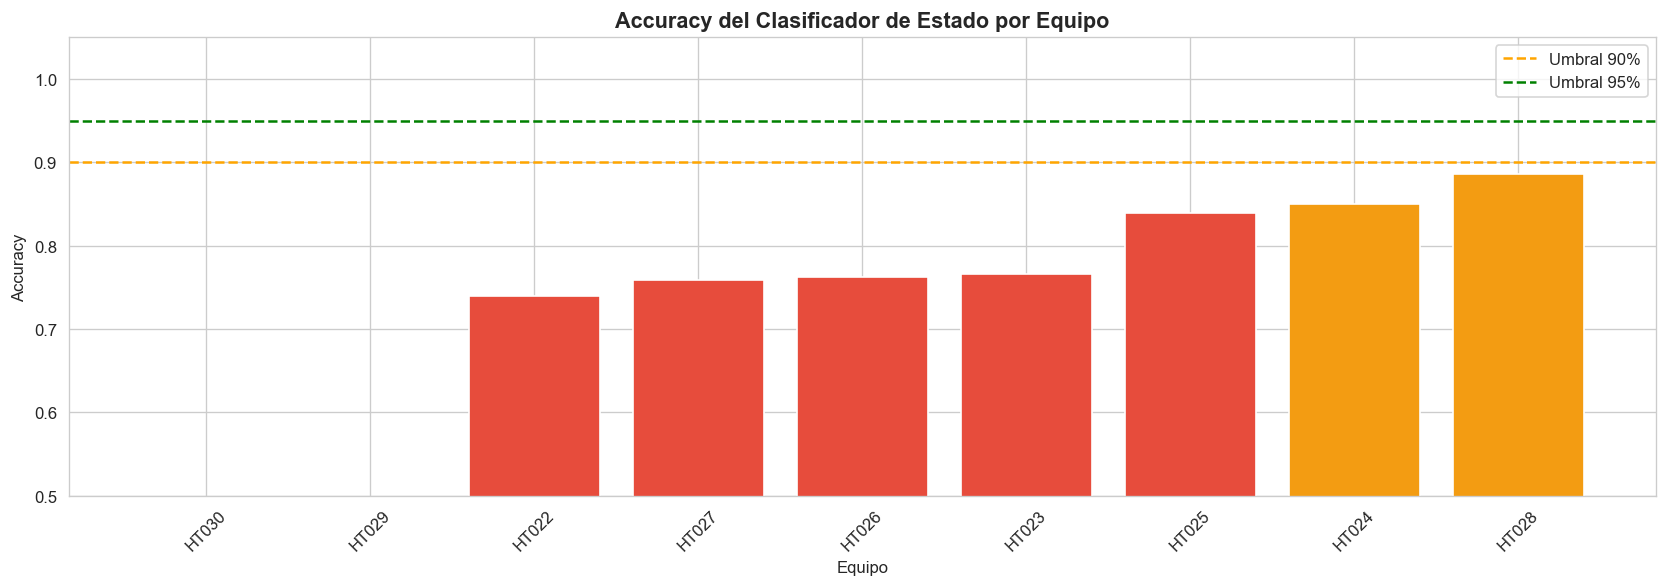

In [26]:
print("=" * 60)
print(" ACCURACY DEL CLASIFICADOR POR EQUIPO")
print("=" * 60)

test_data = df_feat.iloc[split_idx:].copy()
test_data['y_pred_clf'] = y_pred_best_clf
test_data['y_real_clf'] = y_test_c

per_equipo = []
for equipo, grp in test_data.groupby('Equipo'):
    if len(grp) < 5:
        continue
    acc = accuracy_score(grp['y_real_clf'], grp['y_pred_clf'])
    per_equipo.append({
        'Equipo': equipo, 'N': len(grp),
        'Accuracy': round(acc, 4),
        'CRITICO_real': int((grp['y_real_clf'] == 2).sum()),
        'CRITICO_pred': int((grp['y_pred_clf'] == 2).sum()),
        'NORMAL_real':  int((grp['y_real_clf'] == 0).sum()),
        'NORMAL_pred':  int((grp['y_pred_clf'] == 0).sum()),
    })

per_equipo_df = pd.DataFrame(per_equipo).sort_values('Accuracy')
print(per_equipo_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if a < 0.85 else '#f39c12' if a < 0.92 else '#2ecc71'
          for a in per_equipo_df['Accuracy']]
ax.bar(per_equipo_df['Equipo'], per_equipo_df['Accuracy'],
       color=colors, edgecolor='white')
ax.axhline(0.90, color='orange', linestyle='--', label='Umbral 90%')
ax.axhline(0.95, color='green', linestyle='--', label='Umbral 95%')
ax.set_ylim(0.5, 1.05)
ax.set_title('Accuracy del Clasificador de Estado por Equipo', fontsize=13, fontweight='bold')
ax.set_xlabel('Equipo')
ax.set_ylabel('Accuracy')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs_fase2/08_accuracy_por_equipo.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 — Simulación de predicción en tiempo real

Para HT012 y HT001: en cada punto del test set, se muestra cómo el modelo hubiera predicho el estado vs el real, junto con la evolución de horas de producto.

In [27]:
for equipo_demo in ['HT012', 'HT001']:
    grp_demo = test_data[test_data['Equipo'] == equipo_demo].copy()
    if len(grp_demo) < 5:
        print(f"  {equipo_demo}: insuficientes muestras en test, saltando.")
        continue

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle(f'Simulacion en Tiempo Real — {equipo_demo} ({len(grp_demo)} muestras test)',
                 fontsize=13, fontweight='bold')

    x = range(len(grp_demo))

    # Panel superior: estado real vs predicho
    axes[0].plot(x, grp_demo['y_real_clf'].values, 'o-', color='navy',
                 markersize=5, label='Estado Real', linewidth=1.5)
    axes[0].plot(x, grp_demo['y_pred_clf'].values, 's--', color='tomato',
                 markersize=5, label='Estado Predicho', linewidth=1.5)
    axes[0].set_yticks([0, 1, 2])
    axes[0].set_yticklabels(['NORMAL', 'PRECAUCION', 'CRITICO'])
    axes[0].set_title('Prediccion de Estado vs Real')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Marcar aciertos / errores
    for j in x:
        real = grp_demo['y_real_clf'].iloc[j]
        pred = grp_demo['y_pred_clf'].iloc[j]
        if real != pred:
            axes[0].axvspan(j - 0.3, j + 0.3, alpha=0.2, color='red')

    # Panel inferior: Hora_Producto
    axes[1].plot(x, grp_demo['Hora_Producto'].values, 'b-o', markersize=4)
    axes[1].axhline(400, color='orange', linestyle='--', alpha=0.7, label='400h (zona riesgo)')
    axes[1].axhline(500, color='red', linestyle='--', alpha=0.7, label='500h (zona critica)')
    axes[1].set_title('Horas de Producto a lo largo del test')
    axes[1].set_xlabel('Indice de muestra')
    axes[1].set_ylabel('Horas de Producto')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'outputs_fase2/09_simulacion_{equipo_demo}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Simulacion {equipo_demo} generada")

  HT012: insuficientes muestras en test, saltando.
  HT001: insuficientes muestras en test, saltando.


## SECCIÓN 7 — Función de Predicción en Producción

### 7.1 — `predict_next_sample`

Esta es la función que irá en el backend del SaaS. Recibe el historial reciente de un equipo y genera: predicción de estado, valores t+1 y horas restantes hasta CRÍTICO.

In [28]:
def predict_next_sample(historial_equipo: pd.DataFrame,
                        clasificador,
                        regresores: dict,
                        surv_model,
                        vars_lag: list,
                        feature_cols: list,
                        n_lags: int = 5) -> dict:
    """
    Genera predicciones para la proxima muestra de un equipo.

    Args:
        historial_equipo: DataFrame con las ultimas N muestras del equipo,
                          ordenado por Hora_Producto. Columnas requeridas:
                          Hora_Producto, Estado, + vars_lag
        clasificador: modelo de clasificacion de estado entrenado
        regresores: dict {variable: modelo_regresor}
        surv_model: modelo de horas hasta critico
        vars_lag: lista de variables analiticas
        feature_cols: lista de nombres de features esperados por los modelos
        n_lags: numero de lags usados en entrenamiento

    Returns:
        dict con estado_predicho, probabilidades, valores t+1,
        horas restantes, nivel de alerta y mensaje.
    """
    if len(historial_equipo) < n_lags:
        return {'error': f'Se necesitan al menos {n_lags} muestras previas'}

    grp = historial_equipo.sort_values('Hora_Producto').copy()
    estado_to_num = {'NORMAL': 0, 'PRECAUCION': 1, 'CRITICO': 2}
    num_to_estado = {0: 'NORMAL', 1: 'PRECAUCION', 2: 'CRITICO'}

    features = {}

    for var in vars_lag:
        if var not in grp.columns:
            continue
        vals = grp[var].values

        for k in range(1, n_lags + 1):
            idx = -(k)
            features[f'lag{k}_{var[:18]}'] = vals[idx] if abs(idx) <= len(vals) else np.nan

        for k in range(1, n_lags):
            if len(vals) >= k + 1:
                features[f'delta{k}_{var[:18]}'] = vals[-(k)] - vals[-(k + 1)]
            else:
                features[f'delta{k}_{var[:18]}'] = np.nan

        # Rolling sobre las ultimas muestras (sin incluir la "proxima")
        recent = vals[-(min(n_lags + 2, len(vals))):]
        for w in [3, 5]:
            window = recent[-w:] if len(recent) >= w else recent
            valid_w = window[~np.isnan(window)]
            features[f'rollmean{w}_{var[:15]}'] = np.mean(valid_w) if len(valid_w) > 0 else np.nan
            features[f'rollstd{w}_{var[:15]}']  = np.std(valid_w) if len(valid_w) > 1 else 0.0

        valid_recent = recent[~np.isnan(recent)]
        if len(valid_recent) >= 2:
            xi = np.arange(len(valid_recent))
            features[f'trend_{var[:18]}'] = np.polyfit(xi, valid_recent, 1)[0]
        else:
            features[f'trend_{var[:18]}'] = np.nan

    horas = grp['Hora_Producto'].values
    features['horas_actuales']     = horas[-1]
    features['horas_desde_ultima'] = horas[-1] - horas[-2] if len(horas) >= 2 else np.nan
    features['es_cambio_aceite']   = 1 if (len(horas) >= 2 and horas[-1] < horas[-2]) else 0

    estados_num = grp['Estado'].map(estado_to_num).values
    features['estado_lag1'] = estados_num[-1] if len(estados_num) >= 1 else np.nan
    features['estado_lag2'] = estados_num[-2] if len(estados_num) >= 2 else np.nan

    X_pred = pd.DataFrame([features])
    for col in feature_cols:
        if col not in X_pred.columns:
            X_pred[col] = 0.0
    X_pred = X_pred[feature_cols].fillna(0)

    # Prediccion de estado
    estado_cod = int(clasificador.predict(X_pred)[0])
    estado_nombre = num_to_estado.get(estado_cod, 'DESCONOCIDO')

    proba = {}
    if hasattr(clasificador, 'predict_proba'):
        probs = clasificador.predict_proba(X_pred)[0]
        proba = {num_to_estado[i]: round(float(p), 4) for i, p in enumerate(probs)}

    # Prediccion de valores t+1
    valores_pred = {}
    for var, reg_model in regresores.items():
        try:
            valores_pred[var] = round(float(reg_model.predict(X_pred)[0]), 4)
        except Exception:
            valores_pred[var] = None

    # Horas hasta critico
    try:
        horas_critico = max(0, float(surv_model.predict(X_pred)[0]))
    except Exception:
        horas_critico = None

    # Nivel de alerta semaforico
    if estado_nombre == 'CRITICO' or (horas_critico is not None and horas_critico < 100):
        nivel_alerta = 'ROJO'
        mensaje = ('ALERTA CRITICA: Se predice estado CRITICO en la proxima muestra. '
                   'Revisar inmediatamente. Considerar cambio de aceite anticipado.')
    elif estado_nombre == 'PRECAUCION' or (horas_critico is not None and horas_critico < 250):
        nivel_alerta = 'AMARILLO'
        horas_str = f'{horas_critico:.0f}h' if horas_critico else 'N/A'
        mensaje = (f'PRECAUCION: Aceite en degradacion avanzada. '
                   f'Horas estimadas hasta critico: {horas_str}. '
                   'Aumentar frecuencia de muestreo.')
    else:
        nivel_alerta = 'VERDE'
        mensaje = 'NORMAL: Aceite en buen estado. Continuar plan de muestreo regular.'

    return {
        'estado_predicho': estado_nombre,
        'probabilidades_estado': proba,
        'valores_predichos_t1': valores_pred,
        'horas_restantes_hasta_critico': round(horas_critico, 1) if horas_critico is not None else None,
        'nivel_alerta': nivel_alerta,
        'mensaje': mensaje
    }

print("✓ Funcion predict_next_sample definida")

✓ Funcion predict_next_sample definida


### 7.2 — Demo con datos reales

In [29]:
print("=" * 60)
print(" DEMO: Prediccion en Tiempo Real")
print("=" * 60)

for equipo_demo in ['HT012', 'HT001', 'HT009']:
    historial = df[df['Equipo'] == equipo_demo].sort_values('Hora_Producto').tail(10)
    if len(historial) < N_LAGS:
        print(f"\n  {equipo_demo}: historial insuficiente ({len(historial)} muestras)")
        continue

    resultado = predict_next_sample(
        historial_equipo=historial,
        clasificador=best_clf,
        regresores=regression_models,
        surv_model=surv_model,
        vars_lag=VARS_LAG,
        feature_cols=feat_cols,
        n_lags=N_LAGS
    )

    alerta_color = {'ROJO': '\033[91m', 'AMARILLO': '\033[93m', 'VERDE': '\033[92m'}
    reset = '\033[0m'
    color = alerta_color.get(resultado['nivel_alerta'], '')

    print(f"\n  {'='*55}")
    print(f"  EQUIPO {equipo_demo}")
    print(f"  {'='*55}")
    print(f"  Ultima hora registrada: {historial['Hora_Producto'].iloc[-1]}h")
    print(f"  Estado actual:          {historial['Estado'].iloc[-1]}")
    print(f"  Estado predicho (t+1):  {color}{resultado['estado_predicho']}{reset}")
    print(f"  Probabilidades:         {resultado['probabilidades_estado']}")
    print(f"  Horas hasta CRITICO:    {resultado['horas_restantes_hasta_critico']}h")
    print(f"  Nivel de alerta:        {color}{resultado['nivel_alerta']}{reset}")
    print(f"  Mensaje: {resultado['mensaje']}")
    print(f"  Valores predichos t+1 (top 5):")
    for var, val in list(resultado['valores_predichos_t1'].items())[:5]:
        print(f"    {var[:30]:30s}: {val}")

 DEMO: Prediccion en Tiempo Real

  EQUIPO HT012
  Ultima hora registrada: 631h
  Estado actual:          CRITICO
  Estado predicho (t+1):  CRITICO
  Probabilidades:         {'NORMAL': 0.0428, 'PRECAUCION': 0.2338, 'CRITICO': 0.7234}
  Horas hasta CRITICO:    65.9h
  Nivel de alerta:        ROJO
  Mensaje: ALERTA CRITICA: Se predice estado CRITICO en la proxima muestra. Revisar inmediatamente. Considerar cambio de aceite anticipado.
  Valores predichos t+1 (top 5):
    TBN (mg KOH/g)                : 8.114
    Viscosidad a 100 °C cSt       : 13.3889
    Hollin ABS/01 mm              : 0.9616
    Fierro ppm                    : 36.1766
    Oxidación ABS/01 mm           : 0.0418

  EQUIPO HT001
  Ultima hora registrada: 650h
  Estado actual:          PRECAUCION
  Estado predicho (t+1):  CRITICO
  Probabilidades:         {'NORMAL': 0.048, 'PRECAUCION': 0.4331, 'CRITICO': 0.519}
  Horas hasta CRITICO:    53.7h
  Nivel de alerta:        ROJO
  Mensaje: ALERTA CRITICA: Se predice estado CRIT

## SECCIÓN 8 — Exportación Final y Resumen Ejecutivo

### 8.1 — Inventario de modelos y archivos exportados

In [30]:
# Exportar resumen a Excel
with pd.ExcelWriter('outputs_fase2/resumen_fase2_794AC.xlsx', engine='openpyxl') as writer:
    reg_df.to_excel(writer, sheet_name='Resultados_Regresion', index=False)
    per_equipo_df.to_excel(writer, sheet_name='Accuracy_por_Equipo', index=False)
    shap_ranking.to_excel(writer, sheet_name='SHAP_Ranking', index=False)
    pd.DataFrame([{
        'Modelo': 'Supervivencia (horas hasta CRITICO)',
        'MAE_horas': round(mae_surv, 1),
        'RMSE_horas': round(rmse_surv, 1),
        'R2': round(r2_surv, 4),
        'N_test': len(y_te_s)
    }]).to_excel(writer, sheet_name='Supervivencia', index=False)
    pd.DataFrame([{
        'Modelo_clasificador': best_clf_name,
        'Accuracy_LightGBM': round(acc_lgb, 4),
        'Accuracy_XGBoost': round(acc_xgb, 4),
        'N_features': len(feat_cols),
        'N_lags': N_LAGS,
        'N_trials_optuna': N_TRIALS,
        'N_train': len(X_train_c),
        'N_test': len(X_test_c),
    }]).to_excel(writer, sheet_name='Config_Clasificador', index=False)

print("✓ Resumen exportado: outputs_fase2/resumen_fase2_794AC.xlsx")

# Inventario de modelos
print(f"\nModelos exportados en 'models/':")
for f in sorted(os.listdir('models')):
    fpath = os.path.join('models', f)
    size = os.path.getsize(fpath) / 1024
    print(f"  {f} ({size:.1f} KB)")

# Inventario de outputs
print(f"\nOutputs en 'outputs_fase2/':")
for f in sorted(os.listdir('outputs_fase2')):
    print(f"  {f}")

✓ Resumen exportado: outputs_fase2/resumen_fase2_794AC.xlsx

Modelos exportados en 'models/':
  clasificador_estado_xgboost.pkl (873.1 KB)
  estimador_horas_hasta_critico.pkl (844.6 KB)
  feat_cols.json (4.8 KB)
  regresor_Aluminio_ppm.pkl (932.4 KB)
  regresor_Cobre_ppm.pkl (416.5 KB)
  regresor_Cromo_ppm.pkl (321.4 KB)
  regresor_Fierro_ppm.pkl (354.2 KB)
  regresor_Hollin_ABS_01_mm.pkl (340.7 KB)
  regresor_Nitración_ABS_01_mm.pkl (266.3 KB)
  regresor_Oxidación_ABS_01_mm.pkl (442.2 KB)
  regresor_Potasio_ppm.pkl (497.4 KB)
  regresor_Silicio_ppm.pkl (971.1 KB)
  regresor_Sulfatación_ABS_01_mm.pkl (684.3 KB)
  regresor_TBN_(mg_KOH_g).pkl (454.2 KB)
  regresor_Viscosidad_a_100_degC_cSt.pkl (382.0 KB)

Outputs en 'outputs_fase2/':
  01_confusion_matrix_clasificacion.png
  02_resultados_regresion_t1.xlsx
  02b_prediccion_vs_real_regresion.png
  03_shap_clasificador.png
  04_shap_por_clase.png
  05_shap_ranking.xlsx
  06_horas_restantes_distribucion.png
  07_supervivencia_pred_vs_real.p

### 8.2 — Resumen Ejecutivo

In [31]:
n_reg = len(regression_models)

print(f"""
{'='*66}
  RESUMEN EJECUTIVO — FASE 2 MOTOR PREDICTIVO 794AC
{'='*66}

  MODELOS ENTRENADOS:
  + Clasificador de Estado ({best_clf_name} + Optuna)
    Accuracy = {max(acc_lgb, acc_xgb):.4f}
  + Regresores t+1 por variable ({n_reg} modelos LightGBM)
    R2 promedio = {reg_df['R2'].mean():.4f}
  + Estimador de Horas hasta CRITICO (supervivencia)
    MAE = {mae_surv:.1f}h | R2 = {r2_surv:.4f}

  CAPACIDADES DEL SISTEMA:
  -> Predecir si la proxima muestra sera NORMAL/PRECAUCION/CRITICO
  -> Estimar los valores numericos de la proxima muestra
  -> Estimar cuantas horas quedan antes del estado CRITICO
  -> Generar alertas semaforicas (VERDE / AMARILLO / ROJO)
  -> Funcionar con minimo {N_LAGS} muestras de historial del camion

  CORRECCION APLICADA:
  -> Data leakage del rolling_mean corregido con shift(1) previo
  -> Lags que cruzan cambio de aceite invalidados a NaN

  HALLAZGO CLAVE:
  La "hora de quiebre" critica es ~400-450h de producto.
  Por encima de 500h, >67% de muestras son CRITICAS.

  SIGUIENTES PASOS (Fase 3):
  -> Envolver modelos en API REST (FastAPI)
  -> Construir base de datos PostgreSQL
  -> Desarrollar dashboard frontend (React/Streamlit)
  -> Implementar ingesta automatica de nuevas muestras
{'='*66}
""")


  RESUMEN EJECUTIVO — FASE 2 MOTOR PREDICTIVO 794AC

  MODELOS ENTRENADOS:
  + Clasificador de Estado (XGBoost + Optuna)
    Accuracy = 0.7865
  + Regresores t+1 por variable (12 modelos LightGBM)
    R2 promedio = 0.1206
  + Estimador de Horas hasta CRITICO (supervivencia)
    MAE = 46.9h | R2 = 0.2045

  CAPACIDADES DEL SISTEMA:
  -> Predecir si la proxima muestra sera NORMAL/PRECAUCION/CRITICO
  -> Estimar los valores numericos de la proxima muestra
  -> Estimar cuantas horas quedan antes del estado CRITICO
  -> Generar alertas semaforicas (VERDE / AMARILLO / ROJO)
  -> Funcionar con minimo 5 muestras de historial del camion

  CORRECCION APLICADA:
  -> Data leakage del rolling_mean corregido con shift(1) previo
  -> Lags que cruzan cambio de aceite invalidados a NaN

  HALLAZGO CLAVE:
  La "hora de quiebre" critica es ~400-450h de producto.
  Por encima de 500h, >67% de muestras son CRITICAS.

  SIGUIENTES PASOS (Fase 3):
  -> Envolver modelos en API REST (FastAPI)
  -> Construir 